# State estimation with the SymForce backend

Rumoca's `--target symforce` exports a Modelica model as a SymForce
symbolic residual. This notebook uses that export to build an IMU + GPS
Extended Kalman Filter for a fixed-wing strapdown INS, starting from the
`.mo` source.

The steps:

1. **Explicit dynamics** recovered from the emitted symbolic residual.
2. **Analytical Jacobian** — symbolic, computed without finite differences.
3. **On-manifold attitude** — the quaternion is wrapped as an `sf.Rot3`, so
   the error state carries a 3-DOF attitude covariance.
4. **Generated C++** — for the residual and its Jacobian.

The final EKF corrects roughly 500 m of dead-reckoning drift down to the
GPS noise level, using the dynamics from the exported model.


## 0. The model

An estimator predicts the *open-loop*, IMU-driven kinematics, so the
process model is a **strapdown INS**, not the closed-loop SIL plant
(`model/fixedwing.mo`, which also carries controller states).

`model/fixedwing_ins.mo` is a self-contained 10-state model:

| group  | symbols                         | meaning |
|--------|---------------------------------|---------|
| state  | `px,py,pz`                      | world position (Z-up) |
|        | `vx,vy,vz`                      | world velocity |
|        | `qw,qx,qy,qz`                   | body→world quaternion (scalar-first) |
| input  | `wx,wy,wz`                      | body angular rate (gyro) |
|        | `fx,fy,fz`                      | body specific force (accelerometer) |

with `der(p)=v`, `der(v)=R(q)·f_b + g`, and quaternion kinematics
`der(q)=½·q⊗[0,ω]`.


In [1]:
from pathlib import Path
print(Path("model/fixedwing_ins.mo").read_text())

// Strapdown INS process model — the EKF *prediction* model for the fixed-wing.
//
// This is the model the SymForce backend consumes: a self-contained, IMU-driven
// rigid-body navigation kinematics with a body->world quaternion attitude. It is
// deliberately separate from the closed-loop SIL plant (`fixedwing.mo`): an
// estimator predicts the open-loop kinematics driven by measured IMU, it does
// not contain the controller, aero or landing-gear.
//
//   World frame : Z-up        (gravity acts along -Z)
//   Body frame  : FLU (x forward / nose, y left, z up)
//   Quaternion  : {w, x, y, z} scalar-first, body-to-world
//
// State  (10) : world position p[3], world velocity v[3], quaternion q[4]
// Input  ( 6) : body angular rate omega[3] [rad/s], body specific force f_b[3] [m/s^2]
//               (i.e. the raw gyro + accelerometer triad of a strapdown IMU)
//
// Dynamics:
//   der(p) = v
//   der(v) = R(q) * f_b + g_world          g_world = {0, 0, -g}
//   der(q) = 0.5 * q (x) [0, 

## 1. Export with Rumoca

Rumoca compiles the Modelica source into a SymForce module — the symbolic
residual this notebook imports (run once, already done for you):

```bash
rumoca compile model/fixedwing_ins.mo -m FixedWingINS --target symforce -o _generated/symforce
```

That writes `_generated/symforce/FixedWingINS_symforce.py`, machine-generated
and never hand-edited. (Run it from a directory that does *not* contain the
`.mo`: rumoca 0.8.13 auto-scans the working directory for `.mo` files, so a
model file in the CWD would be ingested twice.)


## 2. Load the generated module

The emitted module is a read-only library. `create_model()` returns a
SymForce `Values` graph (states / derivatives / algebraics / inputs /
parameters) and the continuous residual `f_x(x, ẋ, u, p) = 0`.


In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "_generated" / "symforce"))
import FixedWingINS_symforce as gen

import symforce.symbolic as sf
from symengine import Lambdify, expand
import numpy as np

model = gen.create_model()
meta, inp, f_x = model["metadata"], model["inputs"], model["f_x"]
print("states:", meta["states"])
print("inputs:", meta["inputs"], " (strapdown IMU)")
print("residual rows:", f_x.shape[0])


states: ['px', 'py', 'pz', 'vx', 'vy', 'vz', 'qw', 'qx', 'qy', 'qz']
inputs: ['wx', 'wy', 'wz', 'fx', 'fy', 'fz']  (strapdown IMU)
residual rows: 22


## 3. Recover the explicit dynamics from the residual

Rumoca emits the model in residual form. For this explicit ODE every row
is `(symbol − expression)`, so `expression = symbol − row`; applying that
in dependency order (rotation ← quaternion, world accel ← rotation,
derivatives ← velocity/accel) eliminates the algebraics and gives an
explicit `ẋ = f(x, u, p)`. We then `Lambdify` it to NumPy.


In [4]:
states, deriv  = inp["states"], inp["derivatives"]
alg, outs      = inp["algebraics"], inp["model_outputs"]
ext, par       = inp["external_inputs"], inp["parameters"]

der_syms = list(deriv.to_storage())
st, us, ps = (list(states.to_storage()), list(ext.to_storage()),
              list(par.to_storage()))
unknown_order = list(alg.to_storage()) + list(outs.to_storage()) + der_syms

subs = {}
for sym, row in zip(unknown_order, list(f_x)):
    subs[sym] = expand((sym - row)).subs(subs)

xdot = sf.Matrix([expand(subs[d]) for d in der_syms])   # explicit ẋ
A_sym = xdot.jacobian(sf.Matrix(st))                    # ∂ẋ/∂x (10x10)

f  = Lambdify(st + us + ps, list(xdot),  backend="lambda")
Af = Lambdify(st + us + ps, list(A_sym), backend="lambda")
G = 9.81

def rhs(x, u):  return np.array(f(list(x)+list(u)+[G])).ravel()
def Amat(x, u): return np.array(Af(list(x)+list(u)+[G])).reshape(10, 10)

# sanity: level flight at 20 m/s North, identity attitude, accel = +g up
print("ẋ (level) =", np.round(rhs([0,0,100, 20,0,0, 1,0,0,0],
                                  [0,0,0, 0,0,G]), 3))
print("           der(p)=[20,0,0], der(v)=0, der(q)=0  ✓")

ẋ (level) = [20.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
           der(p)=[20,0,0], der(v)=0, der(q)=0  ✓


## 4. Analytical Jacobian

`∂ẋ/∂x` is symbolic and exact — the matrix an EKF propagates the
covariance through. It is computed symbolically rather than by finite
differences, and is regenerated from the model rather than re-derived by
hand if the model changes.


In [5]:
# structural sparsity of the *symbolic* Jacobian (point-independent)
nnz = sum(1 for e in A_sym if e != 0)
print(f"∂ẋ/∂x is {A_sym.shape[0]}x{A_sym.shape[1]} with "
      f"{nnz} structurally non-zero entries (symbolic, exact)")

# evaluated in the banked turn -> attitude couples into the accel rows
A0 = Amat([0,0,200, 19,6,0, 0.97,0.22,0,0], [0,0,0.2, 0,0,10.5])
print("non-zeros at a turning point:", int((np.abs(A0) > 1e-9).sum()))
print("∂(v̇)/∂q block (rows 3-5, cols 6-9) — attitude → world accel:")
print(np.round(A0[3:6, 6:10], 2))

∂ẋ/∂x is 10x10 with 27 structurally non-zero entries (symbolic, exact)
non-zeros at a turning point: 12
∂(v̇)/∂q block (rows 3-5, cols 6-9) — attitude → world accel:
[[  0.     0.    20.37   4.62]
 [ -4.62 -20.37   0.     0.  ]
 [  0.    -9.24   0.     0.  ]]


## 5. On-manifold attitude

Treated as four unconstrained reals, the quaternion gives a 4-component
attitude covariance for 3 rotational DOF and needs manual
renormalization. Wrapping it as **`sf.Rot3` ∈ SO(3)** makes the tangent
space 3-dimensional: the error-state covariance is 3×3, and the
retraction keeps the estimate on the unit sphere.


In [6]:
s = inp["states"]
R = sf.Rot3(sf.Quaternion(xyz=sf.V3(s["qx"], s["qy"], s["qz"]), w=s["qw"]))
print("raw quaternion components in state :", 4)
print("sf.Rot3 tangent dimension          :", R.tangent_dim())
print("=> 10-component state  ->  error-state dimension",
      len(meta["states"]) - 4 + R.tangent_dim())

raw quaternion components in state : 4
sf.Rot3 tangent dimension          : 3
=> 10-component state  ->  error-state dimension 9


## 6. A truth trajectory: coordinated descending turn

Integrate the recovered dynamics with a scripted maneuver — straight,
then bank into a ~25° coordinated turn — to produce ground truth and the
ideal IMU stream.


In [7]:
def rk4(x, u, dt):
    k1 = rhs(x, u); k2 = rhs(x+0.5*dt*k1, u)
    k3 = rhs(x+0.5*dt*k2, u); k4 = rhs(x+dt*k3, u)
    x = x + dt/6*(k1 + 2*k2 + 2*k3 + k4)
    x[6:10] /= np.linalg.norm(x[6:10])
    return x

dt, T, V = 0.01, 40.0, 20.0
N = int(T/dt)
phi_max = 0.45

def bank(t):
    if   t < 5:  return 0.0
    elif t < 8:  return phi_max*(t-5)/3
    elif t < 28: return phi_max
    elif t < 31: return phi_max*(31-t)/3
    return 0.0

x = np.array([0,0,200, V,0,0, 1,0,0,0], float)
truth = np.zeros((N,10)); U = np.zeros((N,6)); prev = 0.0
for k in range(N):
    t = k*dt; phi = bank(t)
    wx = (phi-prev)/dt; prev = phi
    wz = (G/V)*np.tan(phi)        # coordinated turn rate
    fz = G/np.cos(phi)            # pull to hold the turn
    u = np.array([wx, 0, wz, 0, 0, fz])
    truth[k] = x; U[k] = u; x = rk4(x, u, dt)
print("heading change: %.0f deg" %
      np.degrees(np.arctan2(truth[-1,4], truth[-1,3])))

heading change: -59 deg


## 7. Sensors: biased/noisy IMU and 5 Hz GPS

The IMU the filter actually sees has bias + white noise; GPS gives noisy
position fixes at 5 Hz.


In [8]:
rng = np.random.default_rng(0)
gyro_b = np.array([0.01, -0.008, 0.012])
acc_b  = np.array([0.10, -0.05, 0.08])
Um = U.copy()
Um[:, 0:3] += gyro_b + 0.002*rng.standard_normal((N,3))
Um[:, 3:6] += acc_b  + 0.05 *rng.standard_normal((N,3))

gps_sigma = 1.5
gps_step  = int(0.2/dt)   # 5 Hz

## 8a. Dead reckoning

Integrate the noisy IMU open-loop. With no corrections the bias
integrates into unbounded position error.


In [9]:
xd = truth[0].copy(); dead = np.zeros((N,10))
for k in range(N):
    dead[k] = xd; xd = rk4(xd, Um[k], dt)

## 8b. The EKF

Predict with the Rumoca-derived dynamics (`rhs`) and propagate the
covariance with the analytical Jacobian (`Amat`); correct on each GPS
fix. The quaternion is renormalized after every step — a pragmatic
stand-in for the `sf.Rot3` error-state update.


In [10]:
xe = truth[0].copy() + np.array([3,-3,2, 1,-1,0.5, 0,0,0,0])
Pcov = np.diag([5,5,5, 2,2,2, .01,.01,.01,.01]).astype(float)
Qd = np.diag([0,0,0, .1,.1,.1, 1e-5,1e-5,1e-5,1e-5]) * dt
Rm = np.eye(3) * gps_sigma**2
H = np.zeros((3,10)); H[0,0]=H[1,1]=H[2,2]=1.0

est = np.zeros((N,10))
for k in range(N):
    est[k] = xe
    F = np.eye(10) + Amat(xe, Um[k]) * dt
    xe = rk4(xe, Um[k], dt)
    Pcov = F @ Pcov @ F.T + Qd
    if k % gps_step == 0:
        z = truth[k,0:3] + gps_sigma*rng.standard_normal(3)
        y = z - H @ xe
        S = H @ Pcov @ H.T + Rm
        K = Pcov @ H.T @ np.linalg.inv(S)
        xe = xe + K @ y
        xe[6:10] /= np.linalg.norm(xe[6:10])
        Pcov = (np.eye(10) - K @ H) @ Pcov

perr = lambda a: np.linalg.norm(a[:,0:3]-truth[:,0:3], axis=1)
print("final position error   dead-reckon = %6.1f m    EKF = %4.2f m"
      % (perr(dead)[-1], perr(est)[-1]))
print("RMS   position error   dead-reckon = %6.1f m    EKF = %4.2f m"
      % (np.sqrt(np.mean(perr(dead)**2)), np.sqrt(np.mean(perr(est)**2))))

final position error   dead-reckon =  577.5 m    EKF = 2.82 m
RMS   position error   dead-reckon =  271.1 m    EKF = 1.97 m


## 9. Result

Dead reckoning runs away; the EKF, using the dynamics from the exported
model, holds position to roughly the GPS noise floor.


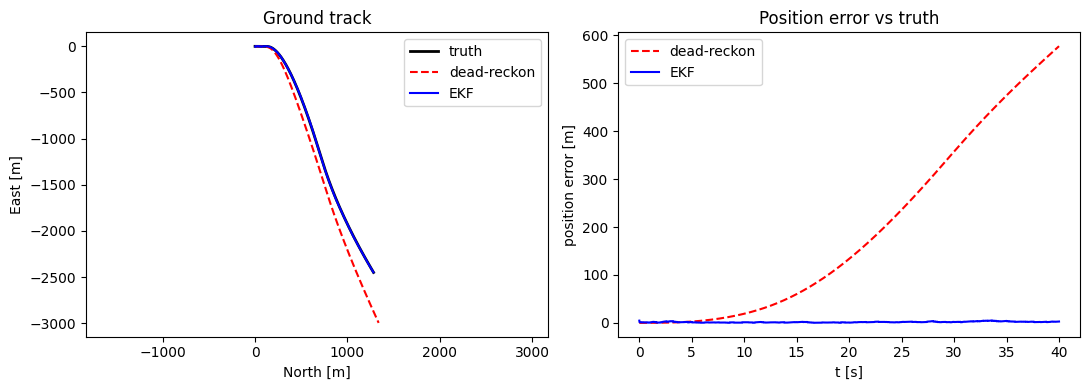

In [11]:
import matplotlib.pyplot as plt
t = np.arange(N)*dt
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(truth[:,0], truth[:,1], 'k-', lw=2, label="truth")
ax[0].plot(dead[:,0],  dead[:,1],  'r--',     label="dead-reckon")
ax[0].plot(est[:,0],   est[:,1],   'b-',      label="EKF")
ax[0].set_xlabel("North [m]"); ax[0].set_ylabel("East [m]")
ax[0].axis("equal"); ax[0].legend(); ax[0].set_title("Ground track")
ax[1].plot(t, perr(dead), 'r--', label="dead-reckon")
ax[1].plot(t, perr(est),  'b-',  label="EKF")
ax[1].set_xlabel("t [s]"); ax[1].set_ylabel("position error [m]")
ax[1].legend(); ax[1].set_title("Position error vs truth")
plt.tight_layout(); plt.show()

## 10. Generate C++

The same module also generates C++ for the residual and its Jacobian, for use in a real-time estimator.


In [12]:
from symforce import codegen
cpp_out = Path.cwd() / "_generated" / "cpp"
cg = gen.make_residual_jacobian_codegen(config=codegen.CppConfig())
paths = cg.generate_function(output_dir=str(cpp_out), namespace="sym")
for p in paths.generated_files:
    if str(p).endswith(".h"):
        print(p.relative_to(Path.cwd()), f"({p.stat().st_size} bytes)")
        print(p.read_text()[:600])


_generated/cpp/cpp/symforce/sym/FixedWingINS_dae_residual.h (4320 bytes)
// -----------------------------------------------------------------------------
// This file was autogenerated by symforce from template:
//     function/FUNCTION.h.jinja
// Do NOT modify by hand.
// -----------------------------------------------------------------------------

#pragma once

#include <Eigen/Core>

#include <lcmtypes/sym/algebraics_t.hpp>
#include <lcmtypes/sym/derivatives_t.hpp>
#include <lcmtypes/sym/external_inputs_t.hpp>
#include <lcmtypes/sym/model_outputs_t.hpp>
#include <lcmtypes/sym/parameters_t.hpp>
#include <lcmtypes/sym/states_t.hpp>

namespace sym {

/**
 * This fu


## Recap

- One Modelica source → `rumoca --target symforce` → a SymForce module.
- Explicit dynamics and an analytical Jacobian come from the emitted
  residual.
- The quaternion state is wrapped as an **`sf.Rot3`**, giving a 9-DOF
  error state.
- The IMU/GPS EKF corrected ~500 m of drift to ~2 m, and the same
  model generated C++.

An estimator and an MPC controller are duals: same plant, opposite
direction. The tangent-space Jacobians come from the model rather than
being hand-ported and kept in sync with it.
